# 02 — Empirical benchmarks and predictive figures
Fits benchmark models under a hospital-aware holdout and exports predictive figures and tables.

In [1]:
# !pip -q install pandas numpy matplotlib scikit-learn openpyxl
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

PROJECT_ROOT = "/content/outputs"
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
TAB_DIR = os.path.join(PROJECT_ROOT, "tables")
INT_DIR = os.path.join(PROJECT_ROOT, "intermediate")
for d in [PROJECT_ROOT, FIG_DIR, TAB_DIR, INT_DIR]:
    os.makedirs(d, exist_ok=True)

DATA_PATH = "analytic_cohort_for_modeling.csv"
COL_HOSPITAL = "hospital_hash"
COL_BRAND = "brand_hash"
COL_AGE = "age_at_year"
COL_CM = "cm_count"
COL_DT = "total_downtime_hours"
COL_Y = "high_downtime_t_plus_1"
TEST_SIZE_HOSPITALS = 0.25
RANDOM_STATE = 42

In [2]:
df = pd.read_csv(DATA_PATH).copy()
df["dt_log1p"] = np.log1p(df[COL_DT])
feature_cols = [COL_AGE, COL_CM, "dt_log1p"]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE_HOSPITALS, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, y=df[COL_Y], groups=df[COL_HOSPITAL]))
np.savez(os.path.join(INT_DIR, "empirical_split_indices.npz"), train_idx=train_idx, test_idx=test_idx)

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)
split_summary = pd.DataFrame({
    "Set": ["Train", "Test"],
    "Observations": [len(train_df), len(test_df)],
    "Hospitals": [train_df[COL_HOSPITAL].nunique(), test_df[COL_HOSPITAL].nunique()],
    "Outcome prevalence": [train_df[COL_Y].mean(), test_df[COL_Y].mean()]
})
display(split_summary)
split_summary.to_csv(os.path.join(TAB_DIR, "table_empirical_split_summary.csv"), index=False)

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()
y_train = train_df[COL_Y].astype(int).values
y_test = test_df[COL_Y].astype(int).values

age_scaler = StandardScaler()
age_scaler.fit(train_df[[COL_AGE]])
p_age = age_scaler.transform(test_df[[COL_AGE]]).ravel()
p_age = (p_age - p_age.min()) / (p_age.max() - p_age.min() + 1e-12)

scaler_heur = StandardScaler()

X_train_scaled_heur = scaler_heur.fit_transform(X_train)
X_test_scaled_heur = scaler_heur.transform(X_test)

score_heur_train = X_train_scaled_heur.sum(axis=1)
score_heur_test = X_test_scaled_heur.sum(axis=1)

# Normalize the test heuristic score to [0, 1] only for ranking/plotting comparability.
# This is not a calibrated probability.
p_heur = (
    score_heur_test - score_heur_test.min()
) / (
    score_heur_test.max() - score_heur_test.min() + 1e-12
)

logit_model = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])
logit_model.fit(X_train, y_train)
p_logit = logit_model.predict_proba(X_test)[:, 1]

gb_model = HistGradientBoostingClassifier(max_iter=250, learning_rate=0.04, max_leaf_nodes=15, random_state=RANDOM_STATE)
gb_model.fit(X_train, y_train)
p_gb = gb_model.predict_proba(X_test)[:, 1]

risk_scores = {
    "Age-only heuristic": p_age,
    "Age + maintenance heuristic": p_heur,
    "Logistic regression": p_logit,
    "Gradient boosting": p_gb,
}

,Set,Observations,Hospitals,Outcome prevalence
0,Train,10517,29,0.289151
1,Test,4292,10,0.155638


,Model,AUROC,AUPRC,Brier,Top-10 capture,Top-5 capture
2,Logistic regression,0.659147,0.275486,0.131354,0.224551,0.104790
3,Gradient boosting,0.655827,0.278391,0.131505,0.252994,0.122754
1,Age + maintenance heuristic,0.654704,0.259263,0.135553,0.206587,0.109281
0,Age-only heuristic,0.551451,0.172849,0.167969,0.116766,0.052395


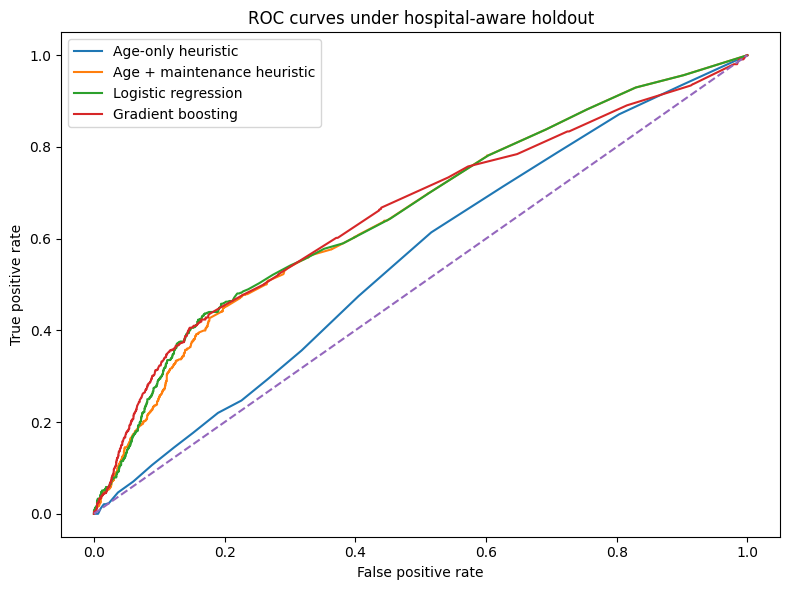

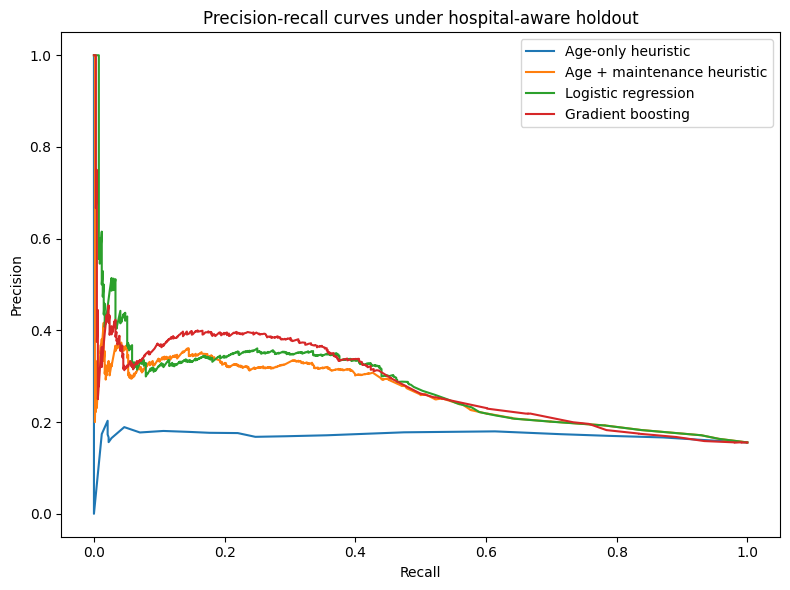

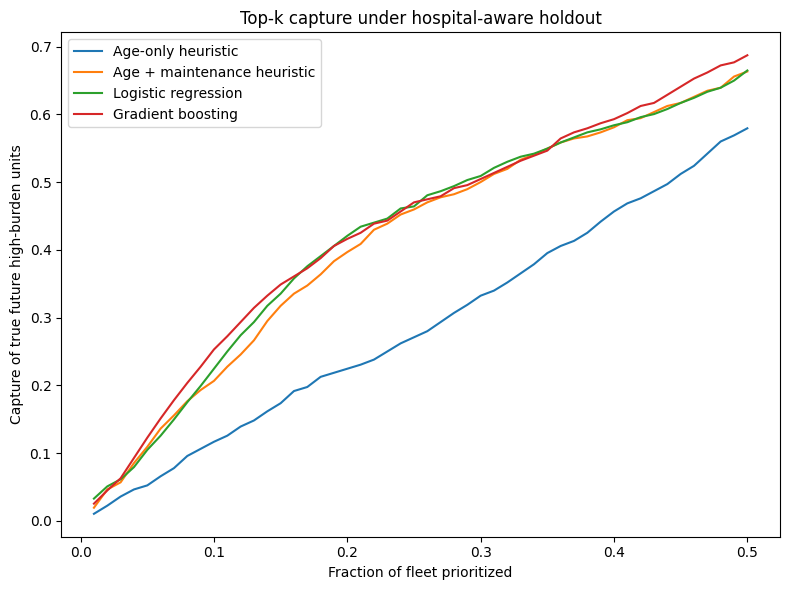

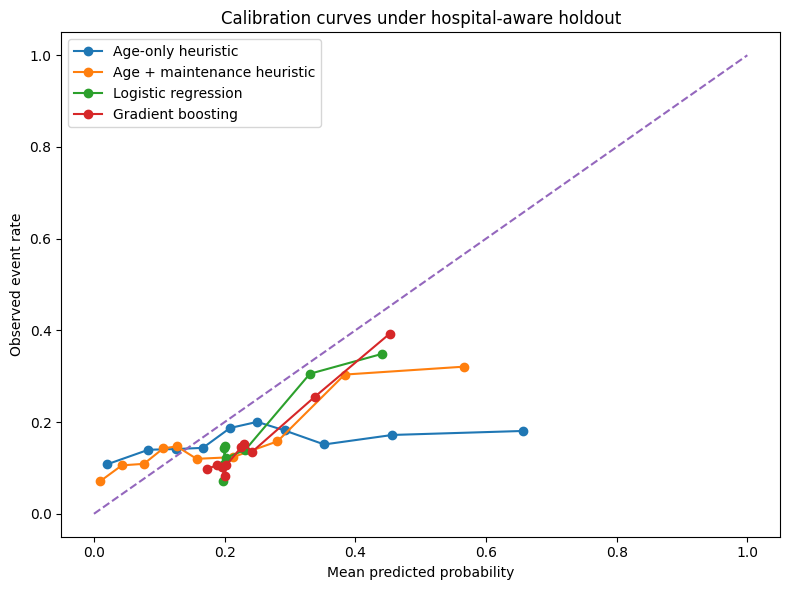

Done.


In [3]:
def top_k_capture(y, p, k_frac=0.10):
    n = len(y)
    k = max(1, int(np.ceil(k_frac * n)))
    idx = np.argsort(-p)[:k]
    positives = y.sum()
    return np.nan if positives == 0 else y[idx].sum() / positives

rows = []
for name, p in risk_scores.items():
    rows.append({
        "Model": name,
        "AUROC": roc_auc_score(y_test, p),
        "AUPRC": average_precision_score(y_test, p),
        "Brier": brier_score_loss(y_test, p),
        "Top-10 capture": top_k_capture(y_test, p, 0.10),
        "Top-5 capture": top_k_capture(y_test, p, 0.05),
    })
perf_df = pd.DataFrame(rows).sort_values("AUROC", ascending=False)
display(perf_df)
perf_df.to_csv(os.path.join(TAB_DIR, "table_predictive_performance.csv"), index=False)
with open(os.path.join(TAB_DIR, "table_predictive_performance.tex"), "w") as f:
    f.write(perf_df.to_latex(index=False, float_format="%.3f"))

plt.figure(figsize=(8,6))
for model_name, p in risk_scores.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label=model_name)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.title("ROC curves under hospital-aware holdout")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_roc_curves.png"), dpi=300)
plt.show()

plt.figure(figsize=(8,6))
for model_name, p in risk_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, p)
    plt.plot(recall, precision, label=model_name)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-recall curves under hospital-aware holdout")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_pr_curves.png"), dpi=300)
plt.show()

k_fracs = np.linspace(0.01, 0.50, 50)
plt.figure(figsize=(8,6))
for model_name, p in risk_scores.items():
    captures = [top_k_capture(y_test, p, k) for k in k_fracs]
    plt.plot(k_fracs, captures, label=model_name)
plt.xlabel("Fraction of fleet prioritized"); plt.ylabel("Capture of true future high-burden units")
plt.title("Top-k capture under hospital-aware holdout")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_topk_capture.png"), dpi=300)
plt.show()

plt.figure(figsize=(8,6))
for model_name, p in risk_scores.items():
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=model_name)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed event rate"); plt.title("Calibration curves under hospital-aware holdout")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "figure_calibration_curves.png"), dpi=300)
plt.show()

pred_df = pd.DataFrame({
    COL_Y: y_test,
    "Age-only heuristic": p_age,
    "Age + maintenance heuristic": p_heur,
    "Logistic regression": p_logit,
    "Gradient boosting": p_gb,
    COL_HOSPITAL: test_df[COL_HOSPITAL].values,
    COL_AGE: test_df[COL_AGE].values,
    COL_CM: test_df[COL_CM].values,
    COL_DT: test_df[COL_DT].values
})
pred_df.to_csv(os.path.join(INT_DIR, "benchmark_test_predictions.csv"), index=False)
test_df.to_csv(os.path.join(INT_DIR, "empirical_test_frame.csv"), index=False)
print("Done.")